Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Class mapping: {'setosa': 0, 'versicolor': 1, 'virginica': 2}

=== Performance vs K ===
 K  Accuracy  Precision   Recall       F1
 1  0.966667   0.969697 0.966667 0.966583
 3  0.933333   0.944444 0.933333 0.932660
 5  0.933333   0.944444 0.933333 0.932660
 7  0.966667   0.969697 0.966667 0.966583
 9  0.966667   0.969697 0.966667 0.966583
11  0.966667   0.969697 0.966667 0.966583
15  0.966667   0.969697 0.966667 0.966583
21  0.966667   0.969697 0.966667 0.966583


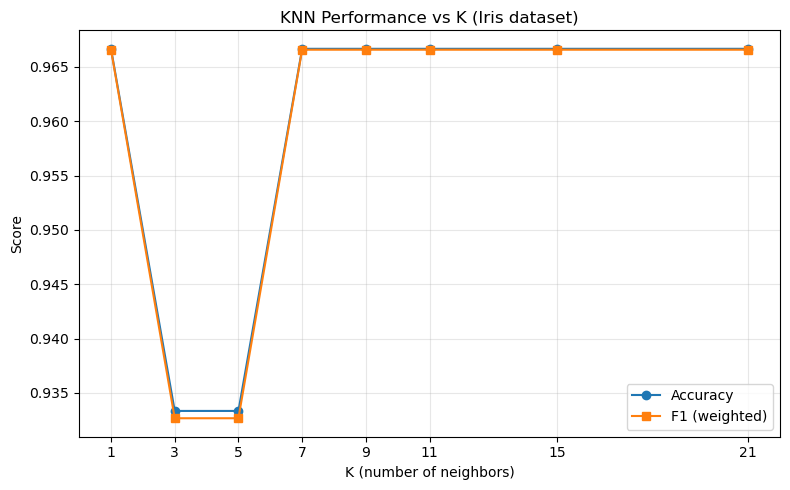


Best K = 1

=== Classification Report (K = 1 ) ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



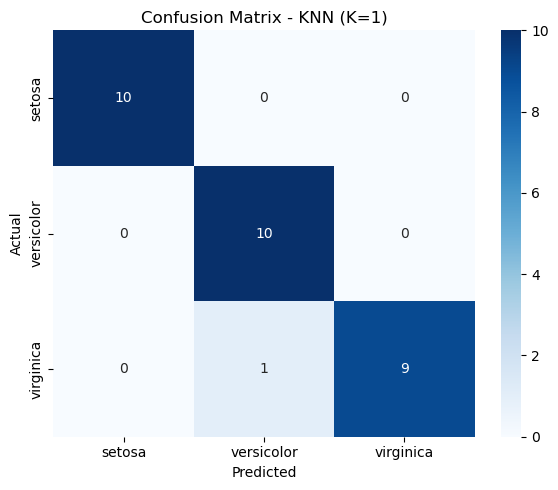

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score)

# 1. Load dataset
df = pd.read_csv(r"C:\Users\250 G7\Desktop\CodeVeda Intern\Dataset\1) iris.csv")
print("Shape:", df.shape)
print(df.head())
print(df["species"].value_counts())

# 2. Preprocess
# Encode target
le = LabelEncoder()
df["species_encoded"] = le.fit_transform(df["species"])
print("\nClass mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = df["species_encoded"]

# Train/test split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# KNN is distance-based -> scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train KNN with different values of K
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "K": k,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
    })

results_df = pd.DataFrame(results)
print("\n=== Performance vs K ===")
print(results_df.to_string(index=False))

# 4. Plot accuracy vs K
plt.figure(figsize=(8, 5))
plt.plot(results_df["K"], results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["K"], results_df["F1"], marker="s", label="F1 (weighted)")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Score")
plt.title("KNN Performance vs K (Iris dataset)")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Best K -> detailed evaluation
best_k = int(results_df.loc[results_df["Accuracy"].idxmax(), "K"])
print(f"\nBest K = {best_k}")

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)

print("\n=== Classification Report (K =", best_k, ") ===")
print(classification_report(
    y_test, y_pred_best, target_names=le.classes_
))

# 6. Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - KNN (K={best_k})")
plt.tight_layout()
plt.show()